In [3]:
from imd_features.config import FeatureSetConfig, GroupConfig
from imd_features.process import create_feature_set
from project_paths import paths, project_root

input_file = project_root / "data/input/combined_data_multi_city.parquet"

In [4]:

minimum_config = FeatureSetConfig(
    name="minimum_curated",
    description="no reduction and the bare minimum features i think have enough information to predict imd",
    groups={
        "uc": GroupConfig(columns=["total_claims"]),
        "crime": GroupConfig(columns=["violent-crime", "total_crimes"]),
        "land_registry": GroupConfig(columns=["lsoa_mean_price", "total_transactions"]),
        "connectivity": GroupConfig(columns=["Overall"]),
        "osm": GroupConfig(columns=["landuse_residential_0"]),
    },
)

df_minimum, metadata = create_feature_set(input_file, minimum_config)

In [6]:
medium_config_path = paths.output / "calibrated_reduction_a5381280_config.json"
medium_config = FeatureSetConfig.model_validate_json(medium_config_path.read_text())
df_medium, _ = create_feature_set(input_file, medium_config)

In [43]:
from pathlib import Path
from project_paths import project_root
import polars as pl

raw = pl.read_parquet(input_file)
engineered = raw.with_columns(
    (pl.col("total_crimes") / pl.col("lsoa_population") * 1000).alias("crime_rate_per_1000"),
    (pl.col("violent-crime") / pl.col("lsoa_population") * 1000).alias("violent_crime_rate"),
    (pl.col("anti-social-behaviour") / pl.col("lsoa_population") * 1000).alias("asb_rate"),
    (pl.col("burglary") / pl.col("lsoa_population") * 1000).alias("burglary_rate"),
    (pl.col("drugs") / pl.col("lsoa_population") * 1000).alias("drugs_rate"),
    (pl.col("total_claims") / pl.col("working_age_population")).alias("uc_claim_rate"),
    (pl.col("total_nwr_claims") / pl.col("working_age_population")).alias("uc_nwr_rate"),
    (pl.col("aged_under_15") / pl.col("lsoa_population")).alias("youth_share"),
    (pl.col("pension_age_population") / pl.col("lsoa_population")).alias("elderly_share"),
    (pl.col("total_transactions") / pl.col("lsoa_population") * 1000).alias("transactions_per_capita"),
)

engineered_path = project_root / "data/input" / "combined_engineered_multi_city.parquet"
engineered.write_parquet(engineered_path)
del raw, engineered

eng_rates_path = paths.output / "engineered_rates_v2_c3ad0464_config.json"
eng_config = FeatureSetConfig.model_validate_json(eng_rates_path.read_text())
df_eng, _ = create_feature_set(project_root / "data/input/combined_engineered_multi_city.parquet", eng_config)

In [44]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.base import clone
from sklearn.metrics import r2_score
from scipy.stats import spearmanr


In [45]:

RANDOM_SEED = 123
N_CV_FOLDS = 5
TARGET_COL = "score"

target_df = pl.read_parquet(paths.reference)

In [46]:

def load_XY(features_df: pl.DataFrame):
    combined = features_df.join(target_df, on="lsoa_code", how="inner")
    feature_cols = [c for c in features_df.columns if c != "lsoa_code"]
    X = combined.select(feature_cols).to_numpy()
    y = combined.select(TARGET_COL).to_numpy().ravel()
    return X, y, feature_cols

In [ ]:
#

In [47]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]

def ridge_alpha_sweep(X, y, alphas, n_splits=5):

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    train_r2s, test_r2s = [], []
    
    for alpha in alphas:

        fold_train, fold_test = [], []

        for train_idx, test_idx in kf.split(X):

            model = Ridge(alpha=alpha)
            model.fit(X[train_idx], y[train_idx])
            fold_train.append(r2_score(y[train_idx], model.predict(X[train_idx])))
            fold_test.append(r2_score(y[test_idx], model.predict(X[test_idx])))

        train_r2s.append(np.mean(fold_train))
        test_r2s.append(np.mean(fold_test))
    
    return np.array(train_r2s), np.array(test_r2s)



In [48]:
X, y, feature_cols = load_XY(df_minimum)

min_train_r2s, min_test_r2s = ridge_alpha_sweep(X, y, alphas)



In [49]:
X, y, feature_cols = load_XY(df_medium)

med_train_r2s, med_test_r2s = ridge_alpha_sweep(X, y, alphas)


In [50]:
X, y, feature_cols = load_XY(df_eng)

eng_train_r2s, eng_test_r2s = ridge_alpha_sweep(X, y, alphas)


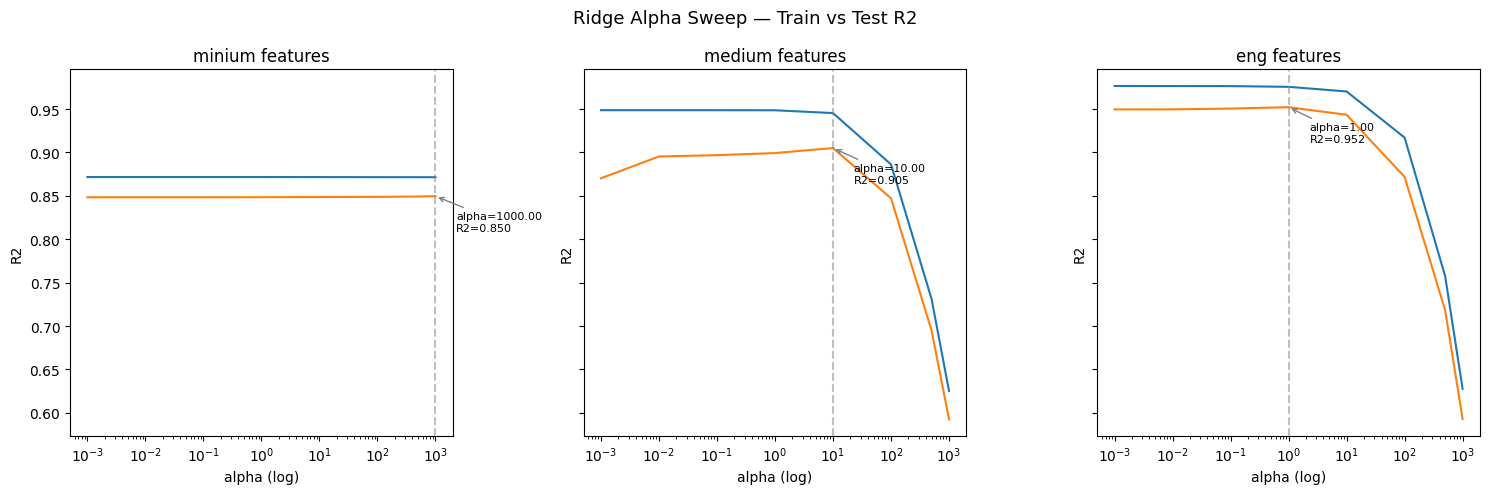

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
ax1, ax2, ax3 = axes


ax1.plot(alphas, min_train_r2s, label="Train R2", linewidth=1.5)
ax1.plot(alphas, min_test_r2s, label="Test R2 (CV)", linewidth=1.5)

best_min = np.argmax(min_test_r2s)
ax1.axvline(alphas[best_min], color="grey", linestyle="--", alpha=0.5)
ax1.annotate(
    f"alpha={alphas[best_min]:.2f}\nR2={min_test_r2s[best_min]:.3f}",
    xy=(alphas[best_min], min_test_r2s[best_min]),
    xytext=(15, -25),
    textcoords="offset points",
    fontsize=8,
    arrowprops=dict(arrowstyle="->", color="grey"),
)
ax1.set_xscale("log")
ax1.set_xlabel("alpha (log)")
ax1.set_ylabel("R2")
ax1.set_title("minium features")



ax2.plot(alphas, med_train_r2s, label="Train R2", linewidth=1.5)
ax2.plot(alphas, med_test_r2s, label="Test R2 (CV)", linewidth=1.5)

best_med = np.argmax(med_test_r2s)
ax2.axvline(alphas[best_med], color="grey", linestyle="--", alpha=0.5)
ax2.annotate(
    f"alpha={alphas[best_med]:.2f}\nR2={med_test_r2s[best_med]:.3f}",
    xy=(alphas[best_med], med_test_r2s[best_med]),
    xytext=(15, -25),
    textcoords="offset points",
    fontsize=8,
    arrowprops=dict(arrowstyle="->", color="grey"),
)
ax2.set_xscale("log")
ax2.set_xlabel("alpha (log)")
ax2.set_ylabel("R2")
ax2.set_title("medium features")



ax3.plot(alphas, eng_train_r2s, label="Train R2", linewidth=1.5)
ax3.plot(alphas, eng_test_r2s, label="Test R2 (CV)", linewidth=1.5)

best_eng = np.argmax(eng_test_r2s)
ax3.axvline(alphas[best_eng], color="grey", linestyle="--", alpha=0.5)
ax3.annotate(
    f"alpha={alphas[best_eng]:.2f}\nR2={eng_test_r2s[best_eng]:.3f}",
    xy=(alphas[best_eng], eng_test_r2s[best_eng]),
    xytext=(15, -25),
    textcoords="offset points",
    fontsize=8,
    arrowprops=dict(arrowstyle="->", color="grey"),
)
ax3.set_xscale("log")
ax3.set_xlabel("alpha (log)")
ax3.set_ylabel("R2")
ax3.set_title("eng features")

fig.suptitle("Ridge Alpha Sweep — Train vs Test R2", fontsize=13)
fig.tight_layout()
plt.savefig("alpha_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

In [62]:
train_sizes = np.array([i/100 for i in range(10, 100, 5)])
# At n=263 these correspond to roughly: 42, 63, 84, 105, 131, 158, 184, 210 training LSOAs

def learning_curve(X, y, model, train_sizes, n_seeds=10, n_splits=5):

    results = {s: [] for s in train_sizes}
    n = len(y)
    
    for seed in range(n_seeds):
        rng = np.random.default_rng(seed)
        for frac in train_sizes:
            n_train = int(n * frac)
            idx = rng.permutation(n)
            train_idx, test_idx = idx[:n_train], idx[n_train:]
            
            m = clone(model)
            m.fit(X[train_idx], y[train_idx])
            results[frac].append(r2_score(y[test_idx], m.predict(X[test_idx])))
    
    means = np.array([np.mean(results[s]) for s in train_sizes])
    stds = np.array([np.std(results[s]) for s in train_sizes])
    return means, stds


In [53]:
X, y, feature_cols = load_XY(df_minimum)
min_means, min_stds = learning_curve(X, y, Ridge(1000), train_sizes)

In [54]:
X, y, feature_cols = load_XY(df_medium)
med_means, med_stds = learning_curve(X, y, Ridge(10), train_sizes)

In [58]:
X, y, feature_cols = load_XY(df_eng)
eng_means, eng_stds = learning_curve(X, y, Ridge(1), train_sizes)

In [56]:
train_ns = [int(i) for i in train_sizes*1273]
train_ns

[127,
 190,
 254,
 318,
 381,
 445,
 509,
 572,
 636,
 700,
 763,
 827,
 891,
 954,
 1018,
 1082,
 1145,
 1209]

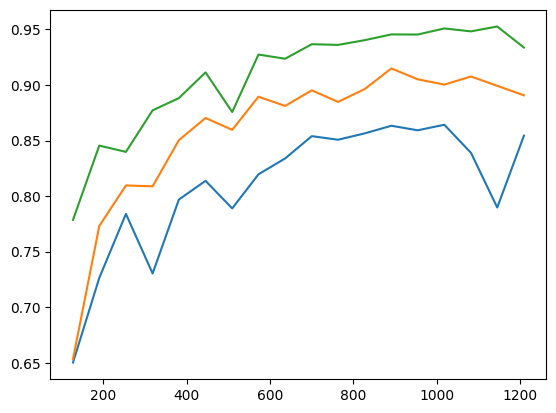

In [59]:
ax = plt.axes()


ax.plot(train_ns, min_means)
ax.plot(train_ns, med_means)
ax.plot(train_ns, eng_means)

plt.show()

# learning rate experiment 2 - using expanded sample

This notebook is follows from the previous one (4 learning rate). Exactly the same feature configurations have been used so that the results can be compared fairly. The change is that we are now using data collected from five other local authority districts: Sheffield, Newcastle, Exeter, Plymouth, and Bournmouth, Poole, and Christchurch. This increases our total sample size from ~250 to ~1250. The intent is to find out how the increased sample affects the total performance and whether i helps improve resistance to overfitting. 

## findings

Some things found in this experiment:

### Overall improvement in performance

As expected from the last experiment (due to learning rate still postitive at 250 observations) the performance of the model has continued to improve as more data has been made available. There has been a very notible increase in the r2 up to an impressive 0.952.

### Plataued learning rate

The curve of the second plot shows that the model is not learning much more past 800 examples. Arguably, the gradiant of the green line is still positive up untill ~1100 and could warrant exploration of further expansion of sample, but since by this point hte model is already very strong and the orange line is completely flat/dipping, I think there are deminishing returns for looking into this further. 

### Affect on overfitting.

There are several findings related to the overfitting problem:

1. Its not eliminated. I expected to see the gap between the blue and orange line in the alpha sweep graph get much closer, but the noticable gap means that there is still overfitting present.
2. reduced best alpha in best config. The best alpha for engineered features has gone from 100 to 1. So way less regularization (basically none) is now needed to achieve the best model. This is exactly what I expected the effect to be . By adding enough data, ridge at low alpah generalises well because there are enough learning examples to estimate stable coefficeints with the penalty coefficient being needed. 

The synthesis of the two above points is that we have added enough data to eliminate the overfitting caused by lack of data, and we can infer that remaining overfitting effect is probably driven by spatial autocorrelation and non independance of the observations. This is good, we can now use this configuration to compare ridge to spatial lag models and make a fair comparision to try and quantify the extent of spatial leakage.

3. overfitting is reduced more in engineered features than in the other two. This suggests that this config of features has less noise. This is useful because it can be a baseline for any further feature engineering. We now know that a well engineered feature set can be used to train models that need little L2 regularisation to perform well. If we find that a high alpha is needed on a future feature config, its a signal that the features contain more noise/less signal than they should.

### The performance is suspiciously high (again)

Can there be a reason we are measuring performance as artificially high? 

## next steps

1. check effect of reordering the examples
2. implement a spatial cross validation method and use it to compare performance of the model using various metrics via standard and spatial cv. This could help estimate the extent of the effect of spatial leakage
3. directly compare spatial lag and normal ridge models
4. train and extensively tune a single model, inc fine tuning feature configs.




i dont actually need to shuffle the features and retrain, i can just use the learning rate function which already averages over ten different permutations (arnt i clever). so i can investigate the stability with different orders by visualising the standard deviation. i actually meant to do this before but couldnt think of how to fit three trends on the graph

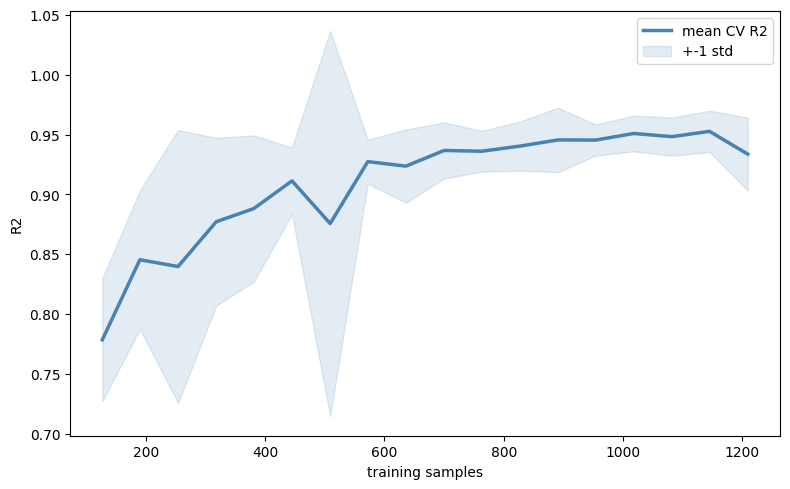

In [65]:
X, y, _ = load_XY(df_eng)
means, stds = learning_curve(X, y, Ridge(1), train_sizes)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_ns, means, color='steelblue', linewidth=2.5, label='mean CV R2')
ax.fill_between(train_ns, means - stds, means + stds, alpha=0.15, color='steelblue', label='+-1 std')
ax.set_xlabel('training samples')
ax.set_ylabel('R2')
ax.legend()
plt.tight_layout()
plt.show()

pleased i decided to collect more data, shap is clearly unstable in first 400 samples. the spikes where the std ribbon widens out are interesting, i wonder if these are where the model starts training on a new city. not sure how well shuffled the different permuatations will be and whether the city boundary effect should be lost in the std measurement after averaging over 10. but the numbers where the r2 dips and std increases look like they roughly line up with addition of lsoa numbers. This could mean that the final model is more general city to city. This could be a good thing, but we are actually trying to frame this project for only bristol, and so we may have actually made the model "worse" for our use case by making it more general.

outcome is that we should definitly explicitly shuffle features before training